In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
weather_df = pd.read_csv('all_weather_by_hour_2023-2026_v1.csv')

In [3]:
weather_df.head(5)

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,...,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,...,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [4]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 808944 entries, 0 to 808943
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         808944 non-null  float64
 1   city_longitude        808944 non-null  float64
 2   city_resolvedAddress  808944 non-null  str    
 3   city_address          808944 non-null  str    
 4   city_timezone         808944 non-null  str    
 5   city_tzoffset         808944 non-null  float64
 6   day_datetime          808944 non-null  str    
 7   day_datetimeEpoch     808944 non-null  int64  
 8   day_tempmax           808944 non-null  float64
 9   day_tempmin           808944 non-null  float64
 10  day_temp              808944 non-null  float64
 11  day_feelslikemax      808944 non-null  float64
 12  day_feelslikemin      808944 non-null  float64
 13  day_feelslike         808944 non-null  float64
 14  day_dew               808944 non-null  float64
 15  day_humidit

In [5]:
weather_df['day_datetime'] = pd.to_datetime(weather_df['day_datetime'])
weather_df['hour_datetime'] = pd.to_datetime(weather_df['hour_datetime'], format='%H:%M:%S')

In [6]:
weather_df['month'] = weather_df['day_datetime'].dt.month
weather_df['hour'] = weather_df['hour_datetime'].dt.hour

In [7]:
weather_df.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,...,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,month,hour
count,808944.000000,808944.000000,808944.0,808944,8.089440e+05,808944.000000,808944.000000,808944.000000,808944.000000,808944.000000,...,808944.000000,808944.000000,808944.000000,401705.000000,808944.000000,801484.000000,718558.000000,801484.000000,808944.000000,808944.000000
mean,49.156104,30.056020,2.0,2024-02-28 07:29:22.938349,1.709096e+09,14.953371,5.952158,10.452933,14.042323,3.895245,...,11.501024,195.965611,1016.748930,16.291253,62.655925,142.053729,0.569854,1.407999,6.471356,11.500000
min,46.472500,22.285100,2.0,2022-02-24 00:00:00,1.645654e+09,-17.100000,-50.300000,-21.600000,-23.200000,-50.300000,...,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.292400,25.935500,2.0,2023-02-25 00:00:00,1.677276e+09,5.900000,-0.200000,2.800000,3.800000,-3.700000,...,7.200000,103.500000,1011.000000,10.000000,27.600000,0.000000,0.000000,0.000000,3.000000,5.750000
50%,49.416800,30.737100,2.0,2024-02-26 00:00:00,1.708898e+09,14.900000,5.900000,10.200000,14.900000,3.900000,...,10.800000,198.400000,1016.400000,11.000000,79.800000,5.500000,0.100000,0.000000,6.000000,11.500000
75%,50.253600,34.551700,2.0,2025-02-27 00:00:00,1.740607e+09,24.400000,12.900000,18.500000,24.400000,12.900000,...,15.100000,290.000000,1022.000000,24.100000,99.700000,217.100000,0.900000,2.000000,9.000000,17.250000
max,51.493700,37.814500,2.0,2026-03-16 00:00:00,1.773612e+09,60.400000,27.200000,33.200000,60.400000,28.000000,...,90.000000,639.000000,1050.000000,75.000000,100.000000,952.000000,3.400000,10.000000,12.000000,23.000000
std,1.339192,4.249937,0.0,NaN,3.680818e+07,10.664279,8.314967,9.309886,11.660104,10.139463,...,6.503900,111.740515,8.491132,9.799102,38.214395,219.688727,0.815547,2.213854,3.453342,6.922191


### Tidy Data & Remove Outliers

In [8]:
weather_df.isnull().sum()

city_latitude           0
city_longitude          0
city_resolvedAddress    0
city_address            0
city_timezone           0
                       ..
hour_icon               0
hour_source             0
hour_stations           0
month                   0
hour                    0
Length: 67, dtype: int64

In [9]:
# Remove temperature outliers using IQR
Q1 = weather_df['hour_temp'].quantile(0.25)
Q3 = weather_df['hour_temp'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

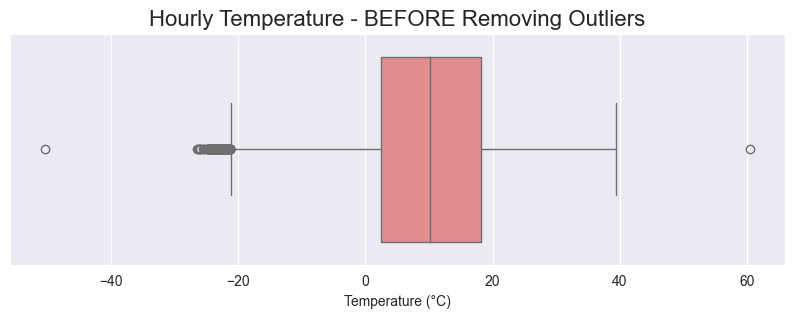

In [10]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=weather_df['hour_temp'], color='lightcoral')
plt.title('Hourly Temperature - BEFORE Removing Outliers', fontsize=16)
plt.xlabel('Temperature (°C)')
plt.show()

In [11]:
outliers_count = len(weather_df[(weather_df['hour_temp'] < lower_bound) | (weather_df['hour_temp'] > upper_bound)])
print(f"Number of outliers detected: {outliers_count}")

Number of outliers detected: 185


In [12]:
weather_df = weather_df[(weather_df['hour_temp'] >= lower_bound) & (weather_df['hour_temp'] <= upper_bound)]

### Visualisations

In [13]:
sns.set_theme(style="whitegrid")

#### Viz 1: Temperature Distribution

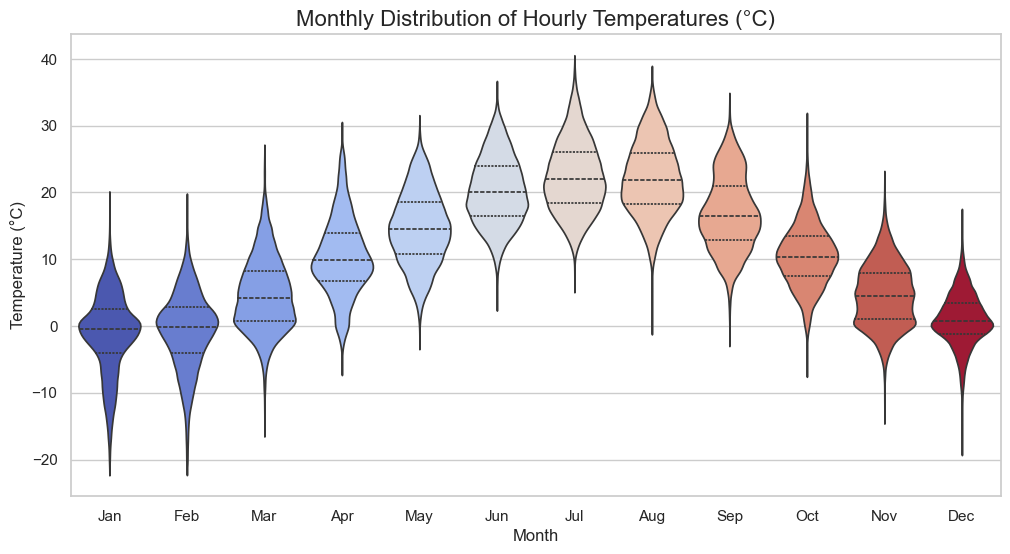

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=weather_df, x='month', y='hour_temp', palette='coolwarm', inner='quartile', hue='month', legend=False)
plt.title('Monthly Distribution of Hourly Temperatures (°C)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

#### Viz 2: Tactical Weather - Visibility by Hour of Day

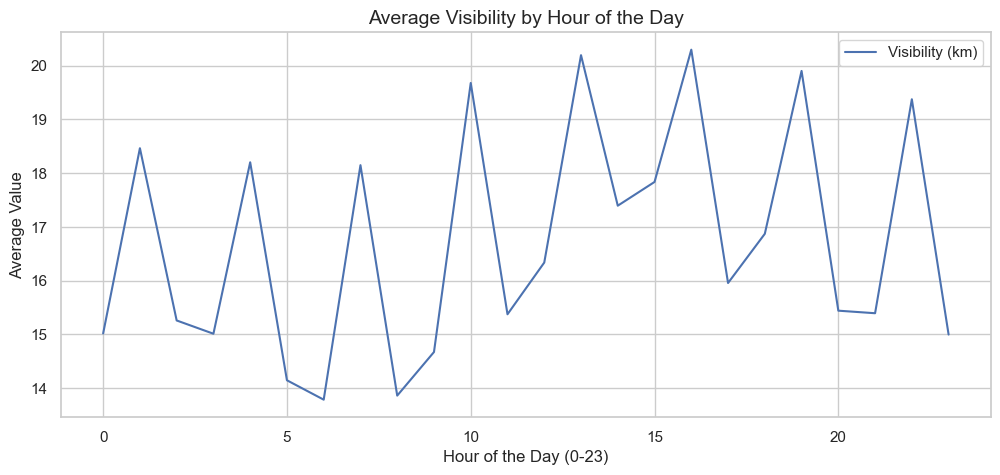

In [15]:
plt.figure(figsize=(12, 5))
hourly_tactical = weather_df.groupby('hour')['hour_visibility'].mean()
sns.lineplot(data=hourly_tactical, markers=True, dashes=False)
plt.title('Average Visibility by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Value')
plt.legend(['Visibility (km)'])
plt.show()

#### Viz 3: Precipitation by Month

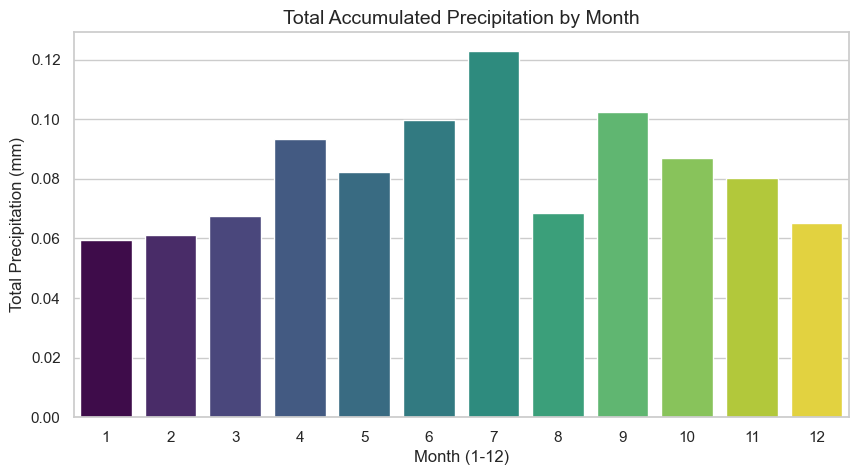

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weather_df, x='month', y='hour_precip', estimator=np.mean, errorbar=None, palette='viridis', hue='month', legend=False)
plt.title('Total Accumulated Precipitation by Month', fontsize=14)
plt.xlabel('Month (1-12)')
plt.ylabel('Total Precipitation (mm)')
plt.show()

#### Viz 4: Frequency of Weather Conditions

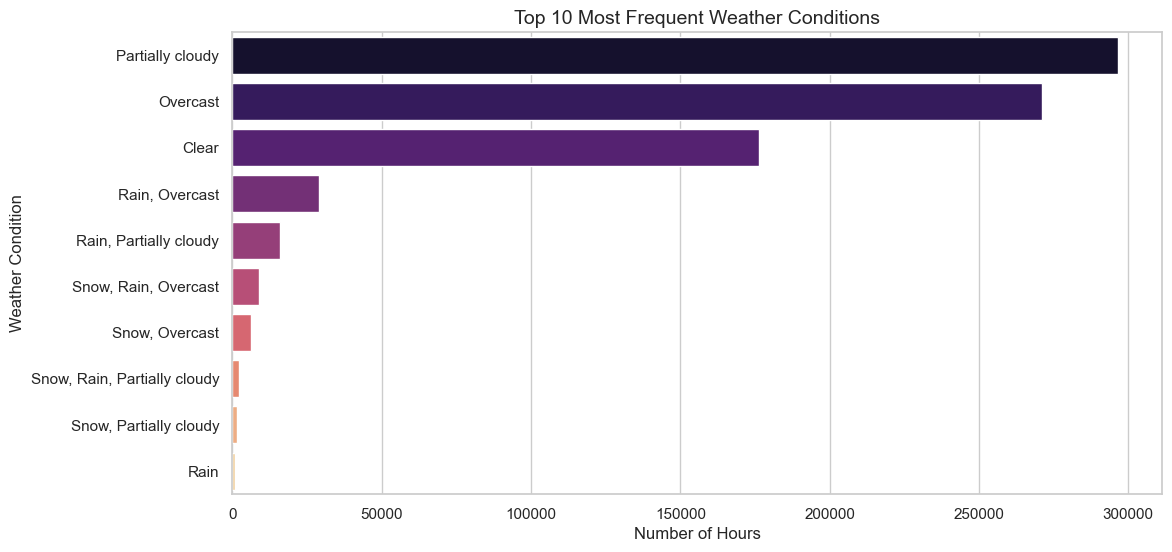

In [17]:
plt.figure(figsize=(12, 6))
top_conditions = weather_df['hour_conditions'].value_counts().head(10)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette='magma', hue=top_conditions.index, legend=False)
plt.title('Top 10 Most Frequent Weather Conditions', fontsize=14)
plt.xlabel('Number of Hours')
plt.ylabel('Weather Condition')
plt.show()

#### Viz 5: Temperature Spread Across Top 10 Cities

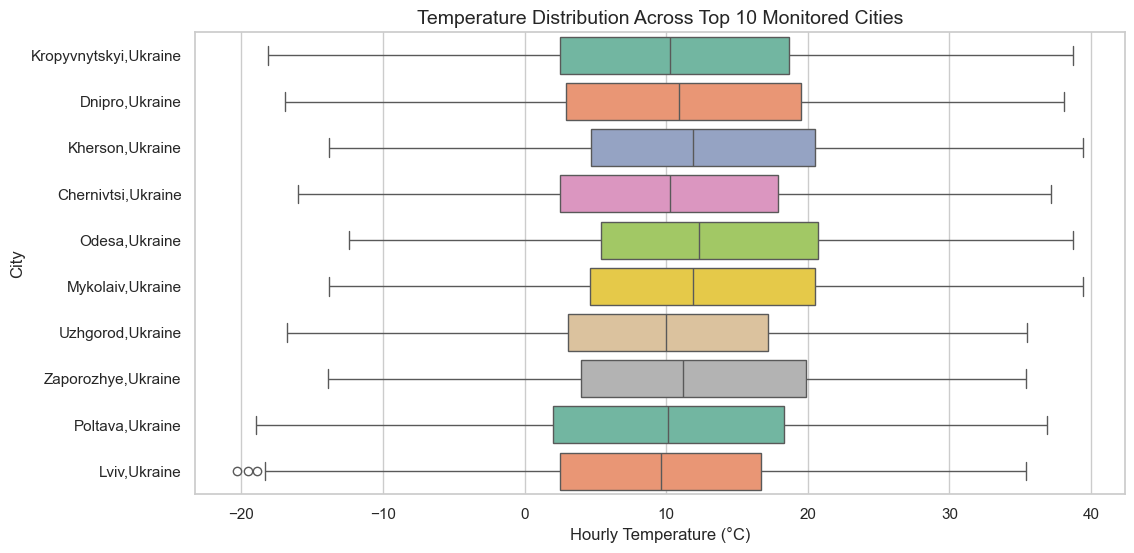

In [18]:
plt.figure(figsize=(12, 6))
top_cities = weather_df['city_address'].value_counts().head(10).index
city_subset = weather_df[weather_df['city_address'].isin(top_cities)]
sns.boxplot(data=city_subset, x='hour_temp', y='city_address', palette='Set2', hue='city_address', legend=False)
plt.title('Temperature Distribution Across Top 10 Monitored Cities', fontsize=14)
plt.xlabel('Hourly Temperature (°C)')
plt.ylabel('City')
plt.show()